1.Librerias y Configuracion.

# Exploratory Data Analysis (EDA)

El objetivo de este análisis exploratorio es:

- Evaluar la calidad del dataset limpio

- Identificar patrones en variables numéricas y categóricas

- Detectar valores atípicos

- Analizar la presencia y comportamiento de valores faltantes

- Identificar relaciones relevantes entre variables

Este análisis servirá como base para decisiones de preprocesamiento y modelado posterior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

plt.rcParams["figure.figsize"] = (10, 5)

2. Carga de datos limpios

Se carga el dataset procesado en 01_carga_datos.ipynb para asegurar consistencia entre la etapa de carga/limpieza y el análisis exploratorio

In [2]:
df = pd.read_csv("../data/dataset_limpio.csv")
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


3. Vista general del dataset

Analizamos dimensiones, tipos de datos, presencia de nulos y una primera estadística descriptiva para entender el rango y la escala de las variables.

In [3]:
df.shape
df.info

<bound method DataFrame.info of        tipo_credito       fecha_prestamo  capital_prestado  plazo_meses  \
0                 7  2024-12-21 11:31:35         3692160.0           10   
1                 4  2025-04-22 09:47:35          840000.0            6   
2                 9  2026-01-08 12:22:40         5974028.4           10   
3                 4  2025-08-04 12:04:10         1671240.0            6   
4                 9  2025-04-26 11:24:26         2781636.0           11   
...             ...                  ...               ...          ...   
10608             9  2025-01-19 16:18:28         2414886.0           10   
10609             4  2025-01-10 16:40:21         2916000.0           24   
10610             4  2025-06-19 14:28:47         4249200.0           36   
10611             9  2025-03-02 11:53:41         1283307.6           10   
10612             4  2024-12-08 12:46:03         3915000.0           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_pr

### Analisis Univariado

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tipo_credito,10613.0,NaN,NaN,NaN,5.361349,2.315674,4.0,4.0,4.0,9.0,68.0
fecha_prestamo,10613,10608,2025-04-10 18:14:34,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital_prestado,10613.0,NaN,NaN,NaN,2386179.781136,1766575.161886,360000.0,1215240.0,1903680.0,3042357.6,28800000.0
plazo_meses,10613.0,NaN,NaN,NaN,10.601338,6.669887,2.0,6.0,10.0,12.0,90.0
edad_cliente,10613.0,NaN,NaN,NaN,42.845661,11.947307,19.0,33.0,42.0,52.0,69.0
tipo_laboral,10613,2,Empleado,6604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,10613.0,NaN,NaN,NaN,7695748.333836,269977793.727253,0.0,2000000.0,3000000.0,4635000.0,22000000000.0
total_otros_prestamos,10613.0,NaN,NaN,NaN,1680308.117874,14967168.138316,0.0,500000.0,1000000.0,2000000.0,1500000000.0
cuota_pactada,10613.0,NaN,NaN,NaN,238497.523509,197736.396153,23944.0,120525.0,181140.0,282862.0,2671342.0
puntaje,10613.0,NaN,NaN,NaN,91.217959,16.329905,-38.00999,95.227787,95.227787,95.227787,95.227787


In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

tendencia_ingresos               2782
promedio_ingresos_datacredito    2780
saldo_mora_codeudor               440
saldo_principal                   256
saldo_mora                          7
saldo_total                         7
puntaje_datacredito                 3
dtype: int64

In [9]:
(missing / len(df) * 100).round(2)[missing > 0]

tendencia_ingresos               26.21
promedio_ingresos_datacredito    26.19
saldo_mora_codeudor               4.15
saldo_principal                   2.41
saldo_mora                        0.07
saldo_total                       0.07
puntaje_datacredito               0.03
dtype: float64

Análisis de patrón en valores faltantes

Se analiza si los valores faltantes en las variables con mayor proporción de missing presentan algún patrón sistemático en relación con otras variables del dataset.

In [20]:
# Crear variable indicadora de missing para tendencia_ingresos
df["tendencia_ingresos_missing"] = df["tendencia_ingresos"].isnull().astype(int)

# Ver proporción de missing por tipo_credito
df.groupby("tipo_credito")["tendencia_ingresos_missing"].mean().sort_values(ascending=False)

tipo_credito
7     0.500000
9     0.292889
4     0.251646
10    0.250000
6     0.190476
68    0.000000
Name: tendencia_ingresos_missing, dtype: float64

In [21]:
# Crear variable indicadora de missing para promedio_ingresos_datacredito
df["promedio_ingresos_missing"] = df["promedio_ingresos_datacredito"].isnull().astype(int)

# Ver proporción de missing por tipo_credito
df.groupby("tipo_credito")["promedio_ingresos_missing"].mean().sort_values(ascending=False)

tipo_credito
7     0.500000
9     0.292522
4     0.251517
10    0.250000
6     0.190476
68    0.000000
Name: promedio_ingresos_missing, dtype: float64

 Conclusión sobre valores faltantes

Se observa que las variables tendencia_ingresos y promedio_ingresos_datacredito presentan una proporción significativa de valores faltantes.

El análisis por tipo_credito evidencia que el missing no es completamente aleatorio, ya que algunos tipos de crédito presentan hasta un 50% de valores faltantes mientras que otros no presentan ninguno.

Esto sugiere que la ausencia de información podría estar asociada a características específicas del tipo de crédito.

En etapas posteriores de modelado se considerará:
- Imputación segmentada por tipo_credito
- Inclusión de variables indicadoras de missing

4. Calidad de datos

Aquí revisamos: nulos, duplicados, valores fuera de rango y consistencia de tipos. Esto es clave porque impacta directamente en modelado y conclusiones.

In [5]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

tendencia_ingresos               2782
promedio_ingresos_datacredito    2780
saldo_mora_codeudor               440
saldo_principal                   256
saldo_mora                          7
saldo_total                         7
puntaje_datacredito                 3
dtype: int64

In [6]:
(nulls / len(df) * 100).round(2)[nulls > 0]

tendencia_ingresos               26.21
promedio_ingresos_datacredito    26.19
saldo_mora_codeudor               4.15
saldo_principal                   2.41
saldo_mora                        0.07
saldo_total                       0.07
puntaje_datacredito               0.03
dtype: float64

In [ ]:
df["tendencia_ingresos_missing"] = df["tendencia_ingresos"].isna().astype(int)

df.groupby("tipo_credito")["tendencia_ingresos_missing"].mean().sort_values(ascending=False) * 100

tipo_credito
7     50.000000
9     29.288856
4     25.164622
10    25.000000
6     19.047619
68     0.000000
Name: tendencia_ingresos_missing, dtype: float64

In [25]:
df["promedio_ingresos_missing"] = df["promedio_ingresos_datacredito"].isna().astype(int)

df.groupby("tipo_credito")["promedio_ingresos_missing"].mean().sort_values(ascending=False) * 100

tipo_credito
7     50.000000
9     29.252199
4     25.151711
10    25.000000
6     19.047619
68     0.000000
Name: promedio_ingresos_missing, dtype: float64

In [26]:
df.duplicated().sum()

np.int64(0)

5. Separación de variables numéricas y categóricas

Esto permite aplicar técnicas diferentes para cada tipo de variable y estructurar el análisis de manera clara.

In [10]:
#Identificar columnas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['tipo_credito',
  'capital_prestado',
  'plazo_meses',
  'edad_cliente',
  'salario_cliente',
  'total_otros_prestamos',
  'cuota_pactada',
  'puntaje',
  'puntaje_datacredito',
  'cant_creditosvigentes',
  'huella_consulta',
  'saldo_mora',
  'saldo_total',
  'saldo_principal',
  'saldo_mora_codeudor',
  'creditos_sectorFinanciero',
  'creditos_sectorCooperativo',
  'creditos_sectorReal',
  'promedio_ingresos_datacredito',
  'Pago_atiempo'],
 ['fecha_prestamo', 'tipo_laboral', 'tendencia_ingresos'])

In [27]:
# Convertir tipo_credito a categórica
df["tipo_credito"] = df["tipo_credito"].astype("object")

# Recalcular columnas
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_cols, cat_cols

(['capital_prestado',
  'plazo_meses',
  'edad_cliente',
  'salario_cliente',
  'total_otros_prestamos',
  'cuota_pactada',
  'puntaje',
  'puntaje_datacredito',
  'cant_creditosvigentes',
  'huella_consulta',
  'saldo_mora',
  'saldo_total',
  'saldo_principal',
  'saldo_mora_codeudor',
  'creditos_sectorFinanciero',
  'creditos_sectorCooperativo',
  'creditos_sectorReal',
  'promedio_ingresos_datacredito',
  'Pago_atiempo',
  'tendencia_ingresos_missing',
  'promedio_ingresos_missing'],
 ['tipo_credito', 'fecha_prestamo', 'tipo_laboral', 'tendencia_ingresos'])

6. Distribución de variables numéricas

Revisamos histogramas y boxplots para detectar: asimetrías, colas largas, concentración de valores, posibles outliers.
Esto ayuda a decidir: escalado, transformaciones (log), winsorización o filtros.

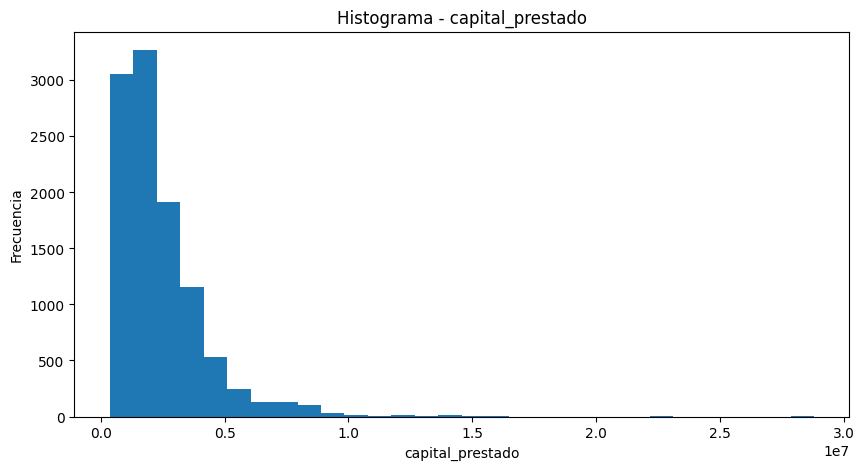

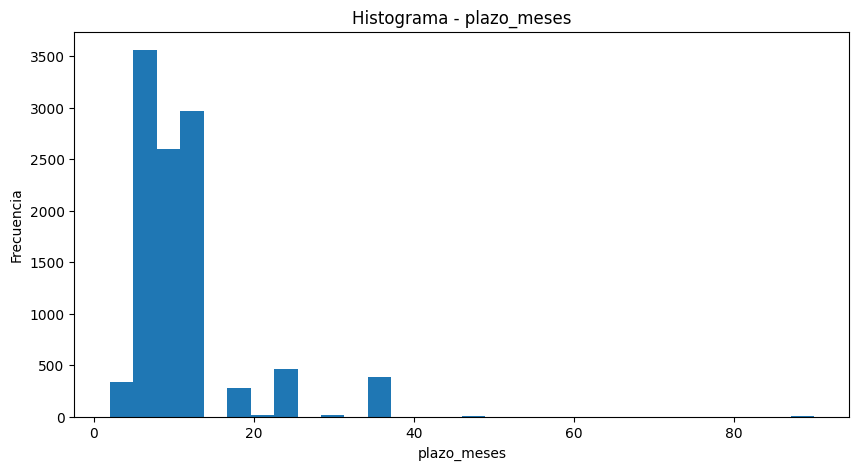

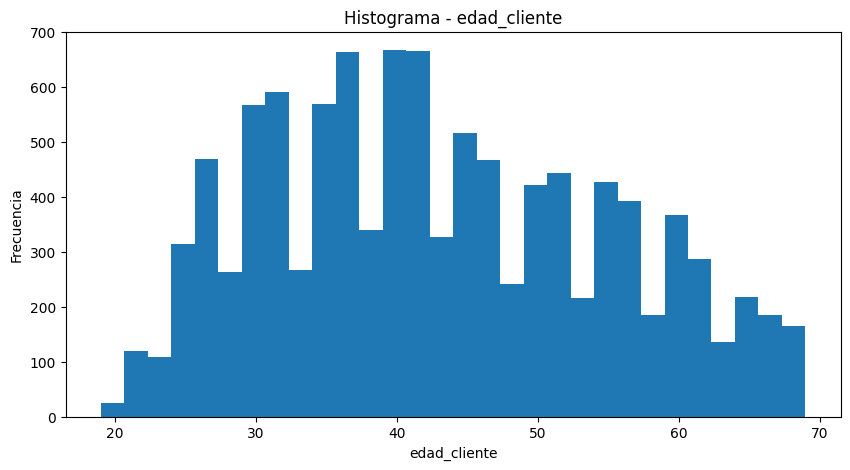

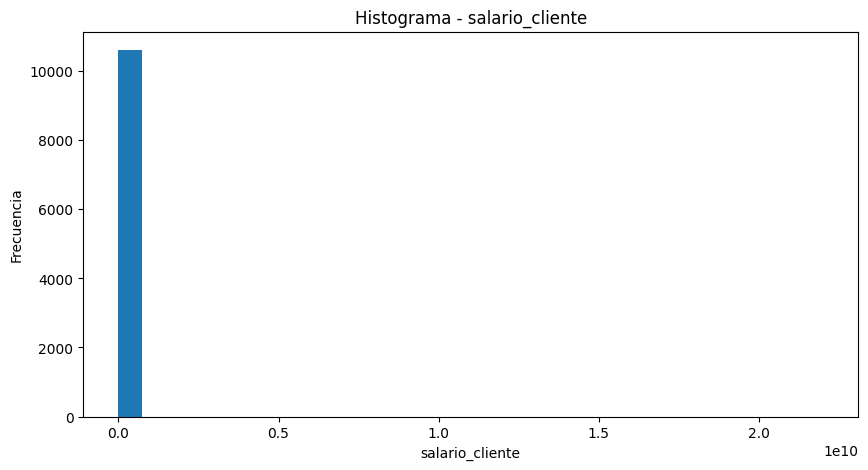

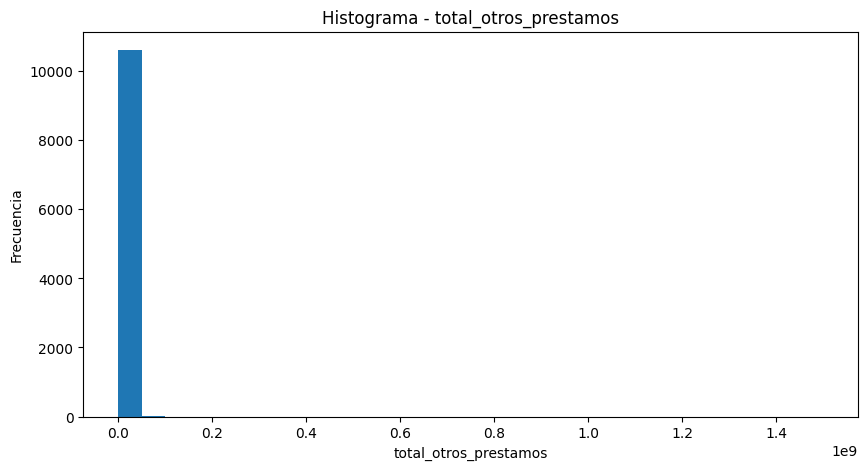

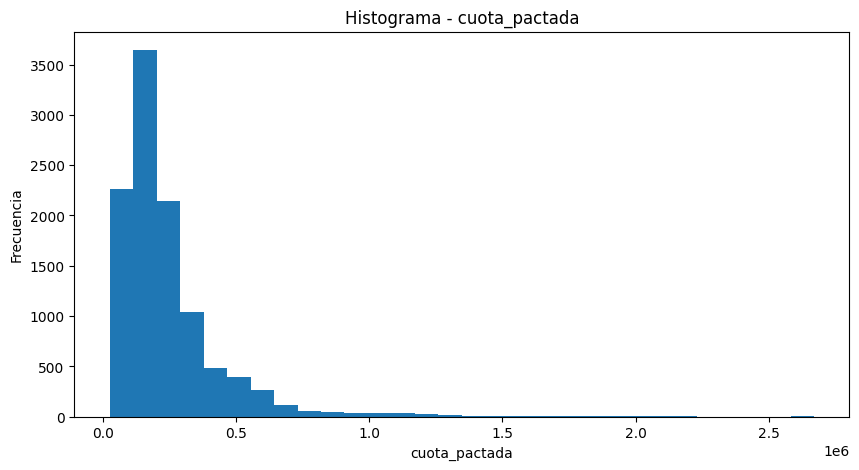

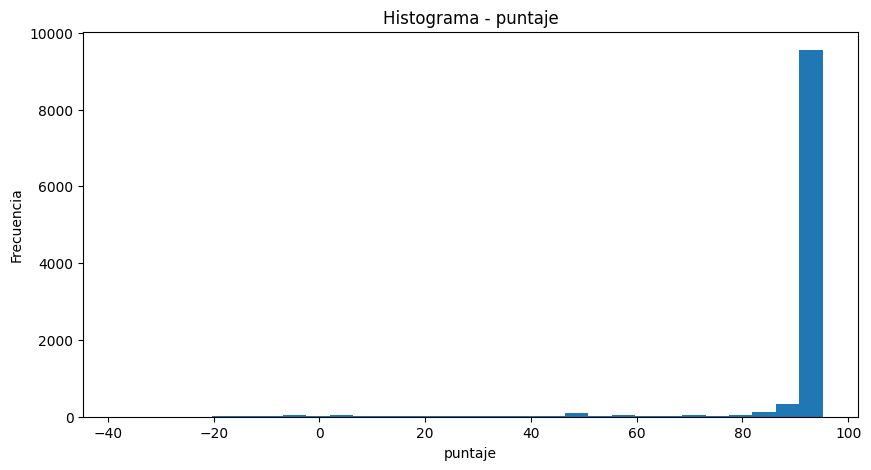

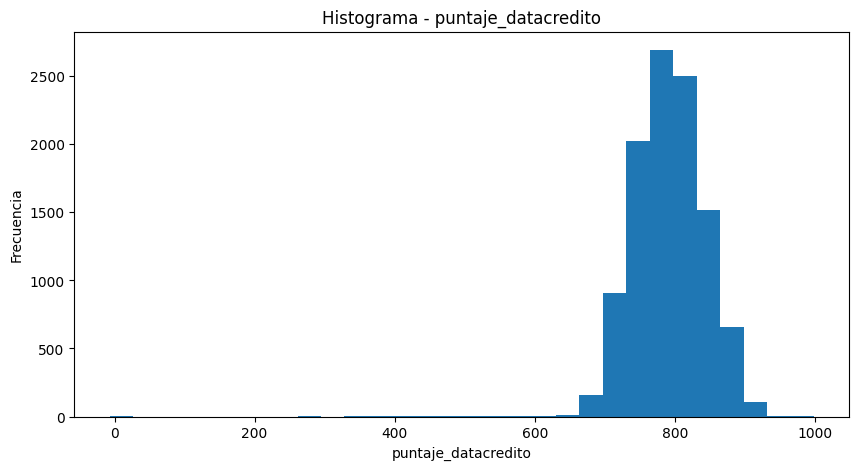

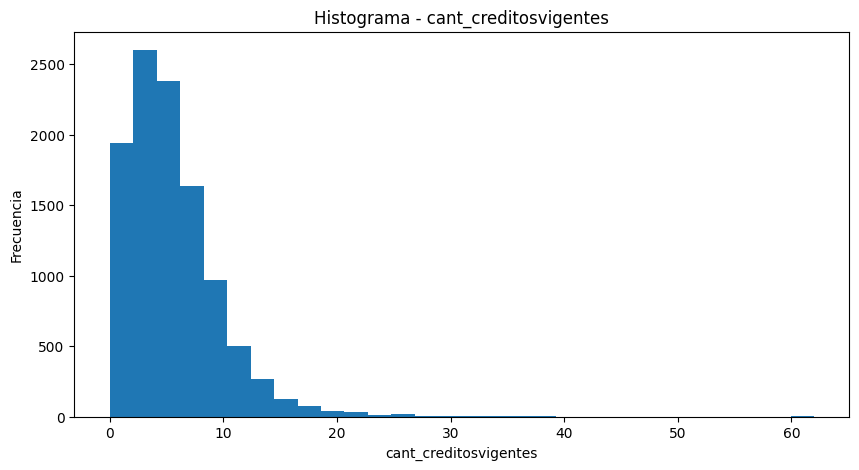

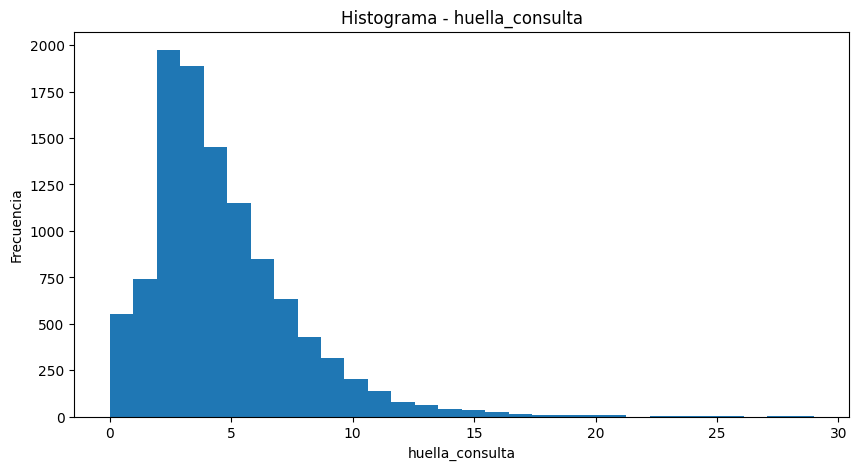

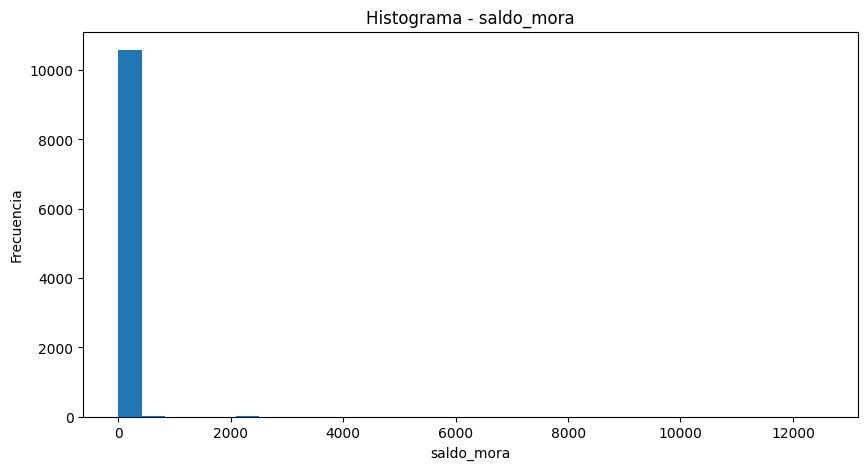

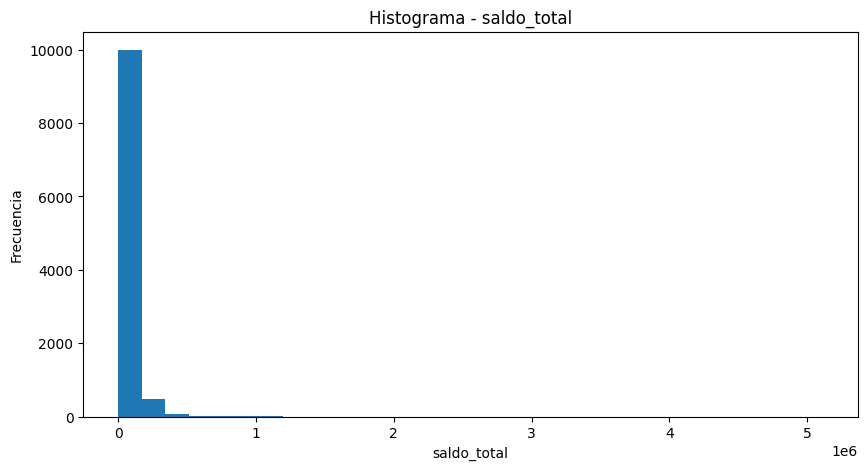

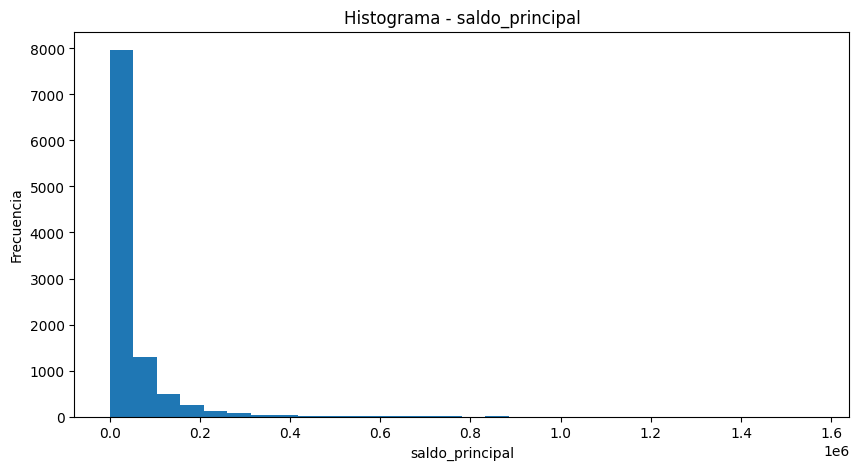

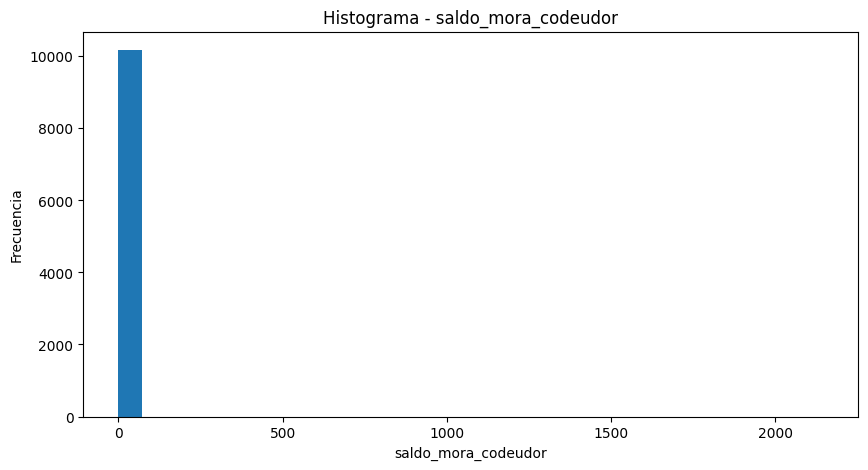

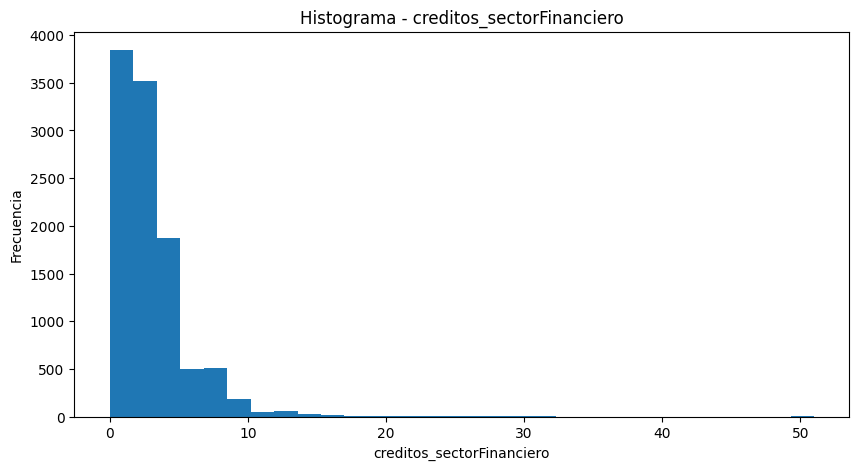

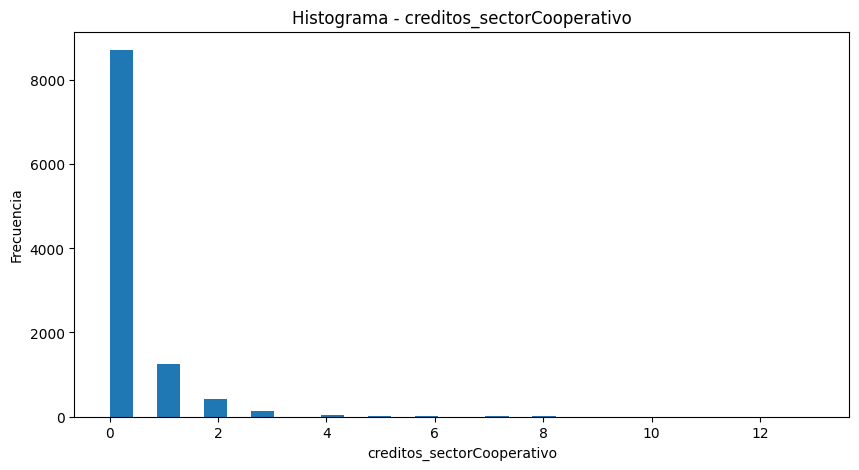

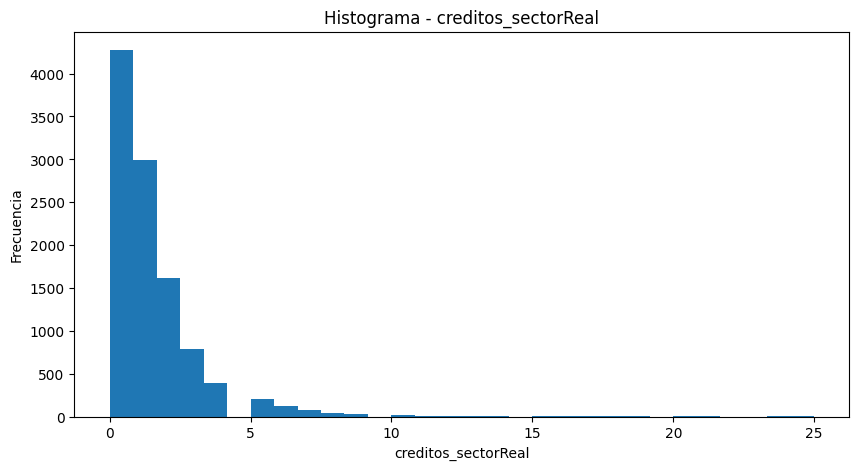

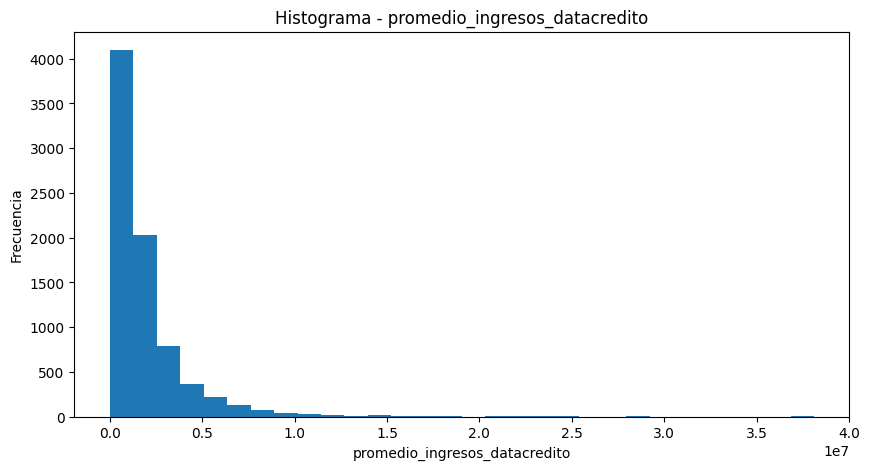

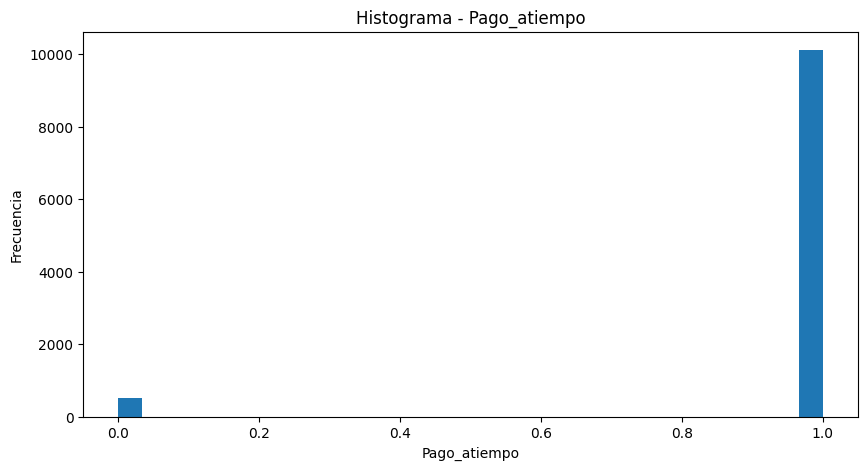

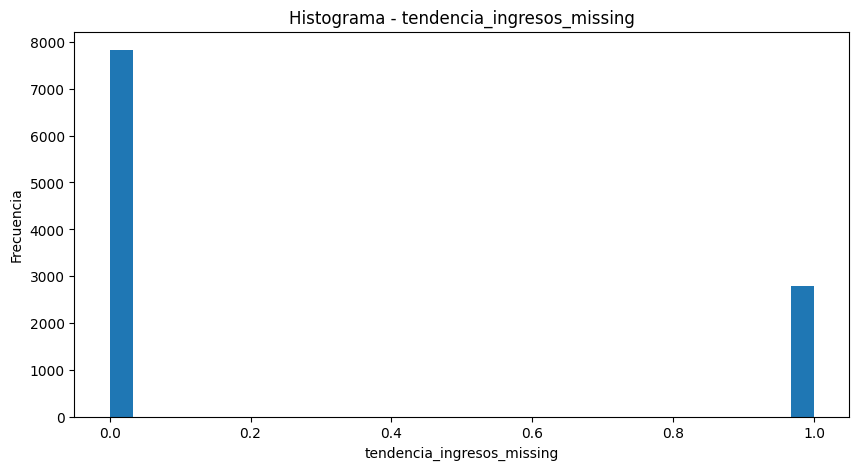

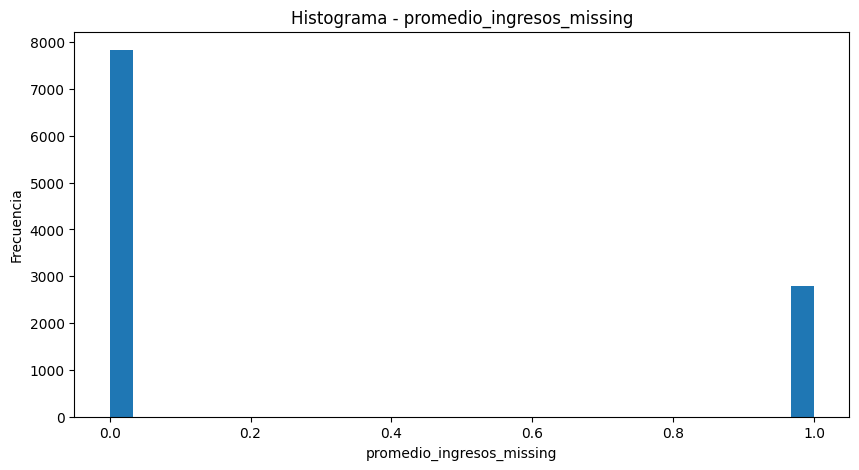

In [28]:
#Histogramas(numericas)
for col in num_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histograma - {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Interpretación de Histogramas

El análisis de histogramas permite evaluar la forma de las distribuciones,
identificar asimetrías y detectar posibles valores extremos.

Principales hallazgos:

- La mayoría de las variables monetarias (capital_prestado, saldo_total,
  salario_cliente, promedio_ingresos_datacredito, cuota_pactada)
  presentan asimetría positiva marcada, con concentración de valores bajos
  y colas largas hacia valores elevados.

- Este comportamiento es consistente con datos financieros reales,
  donde pocos clientes concentran montos significativamente altos.

- Variables de conteo como cant_creditosvigentes,
  creditos_sectorFinanciero, huella_consulta
  muestran distribución discreta y sesgada, lo cual es esperado
  en variables que representan frecuencia.

- La variable edad_cliente presenta distribución razonable,
  sin evidencia de valores atípicos extremos tras la limpieza realizada.

- La variable Pago_a_tiempo muestra naturaleza binaria y desbalance
  hacia la categoría positiva.

Implicancias para modelado

Las distribuciones altamente asimétricas sugieren evaluar:

- Transformaciones logarítmicas.
- Escalado robusto.
- Técnicas adecuadas para tratar desbalance en variables binarias

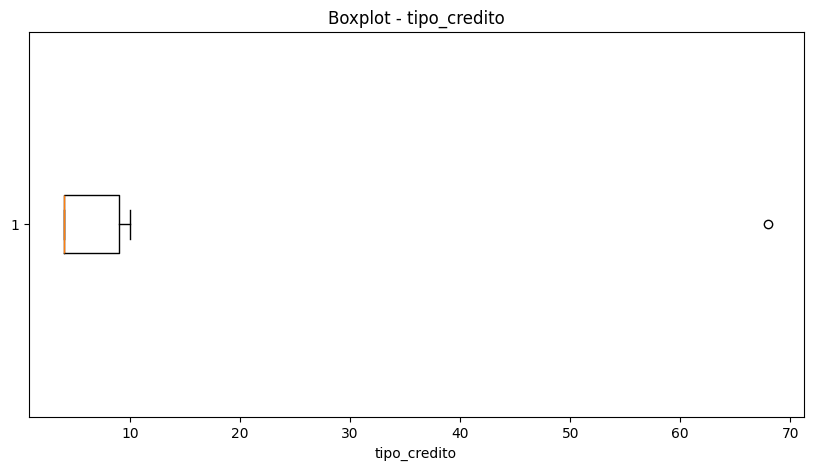

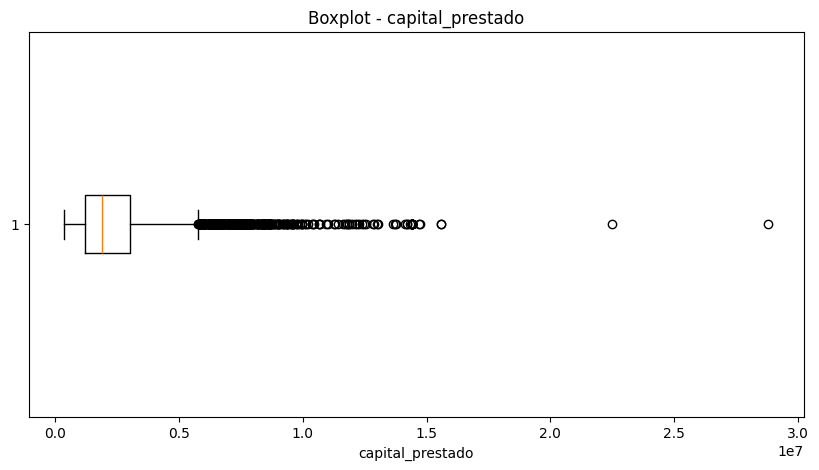

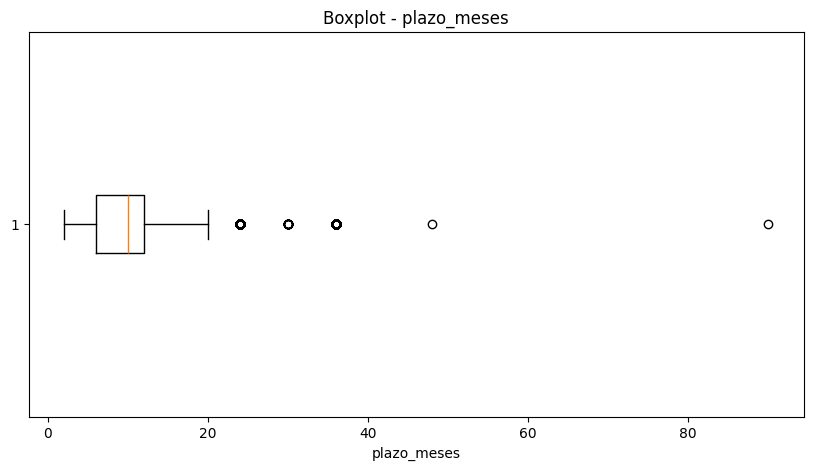

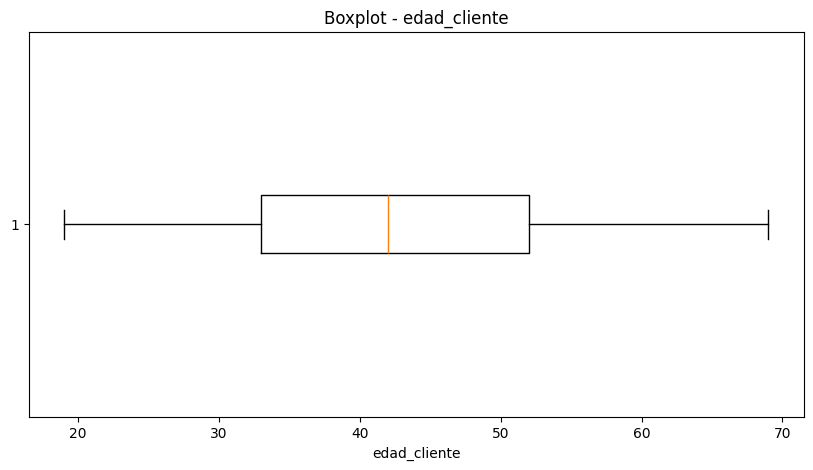

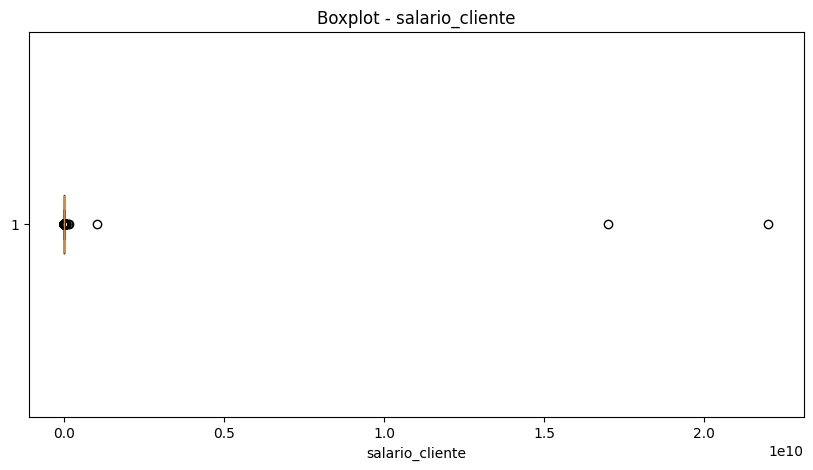

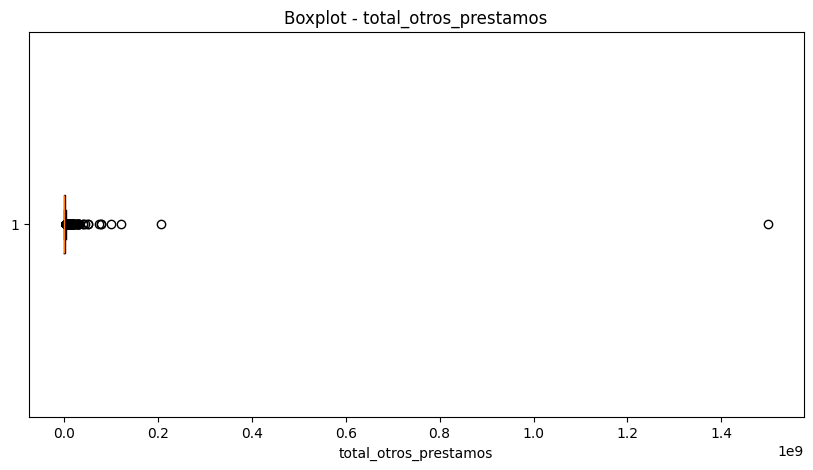

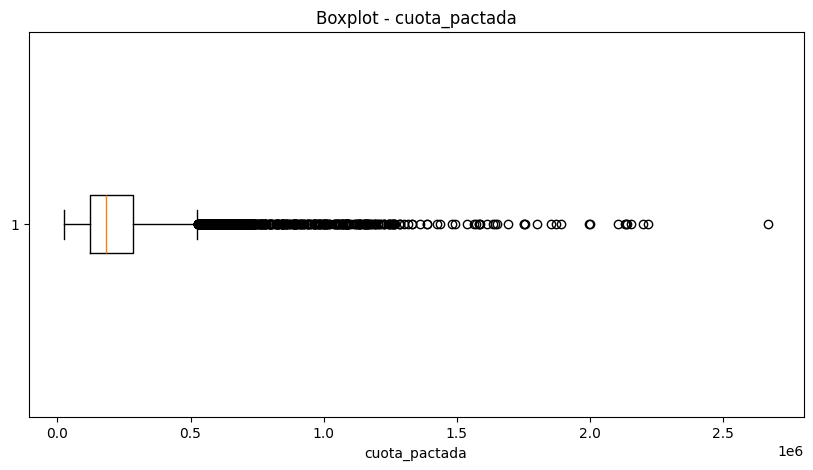

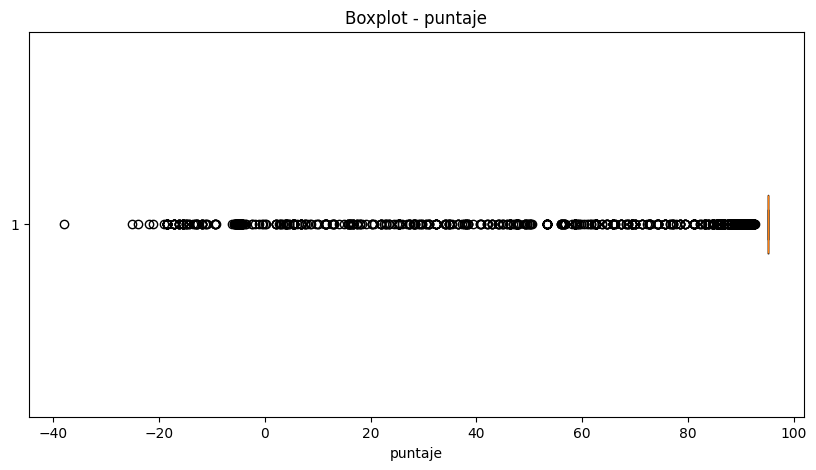

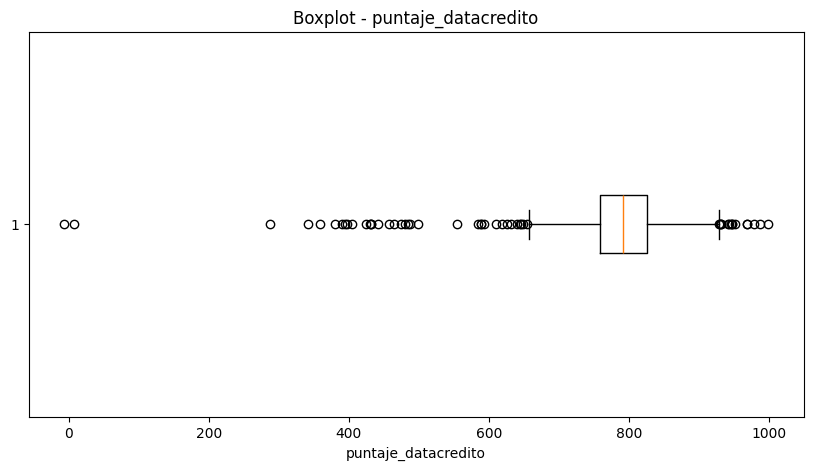

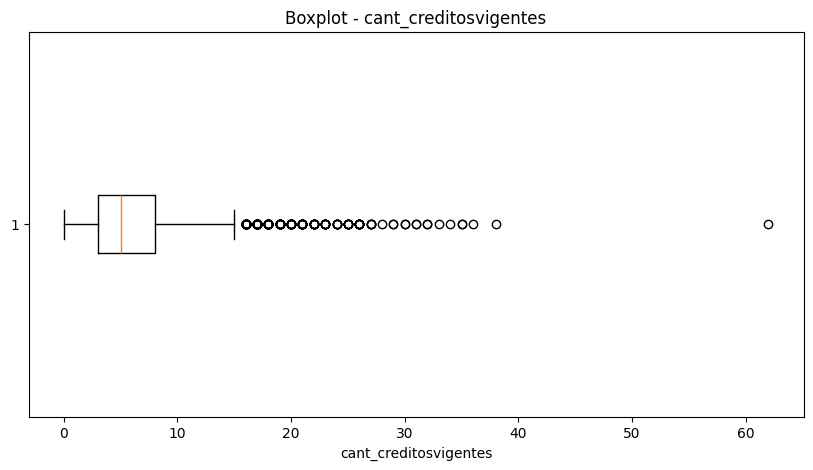

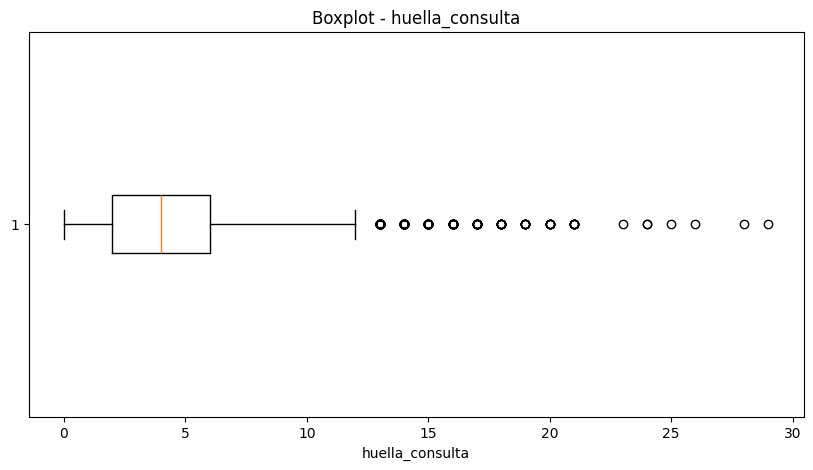

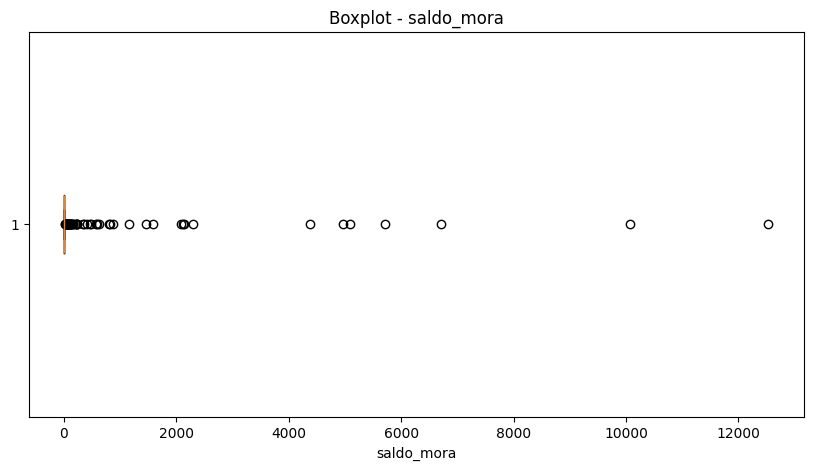

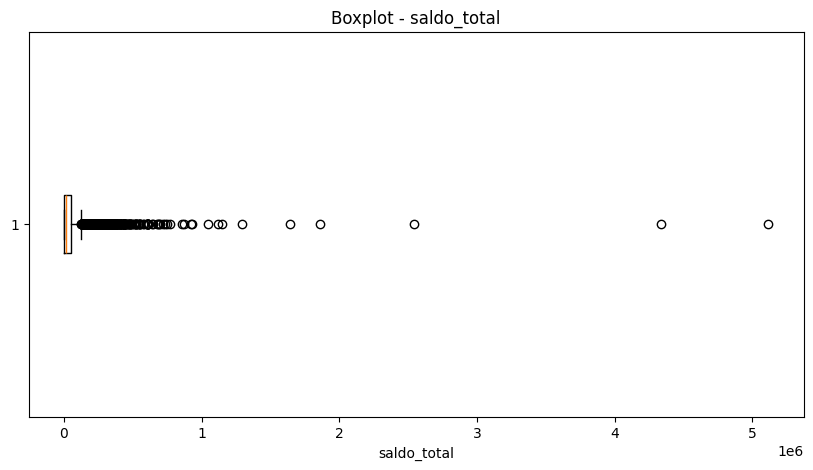

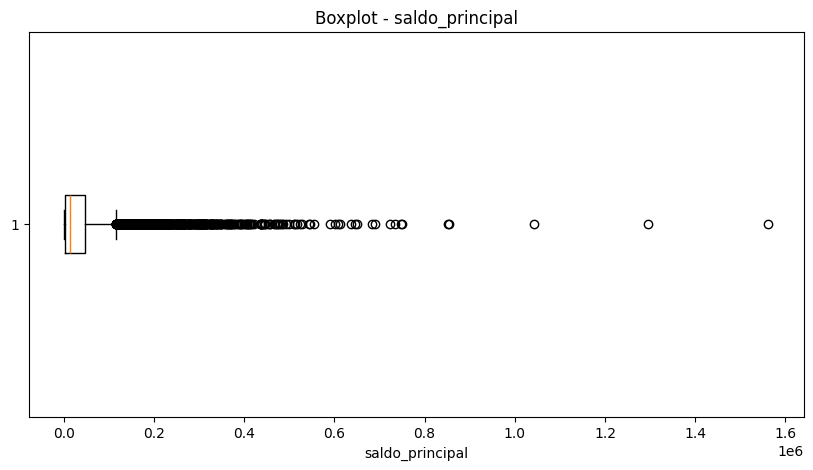

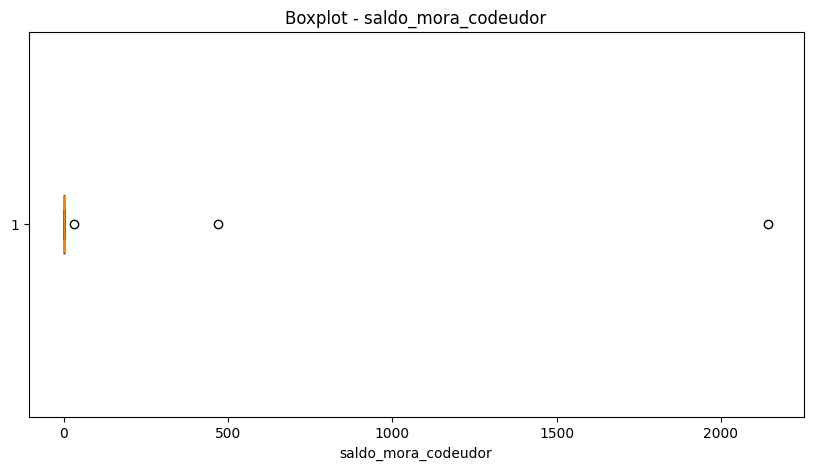

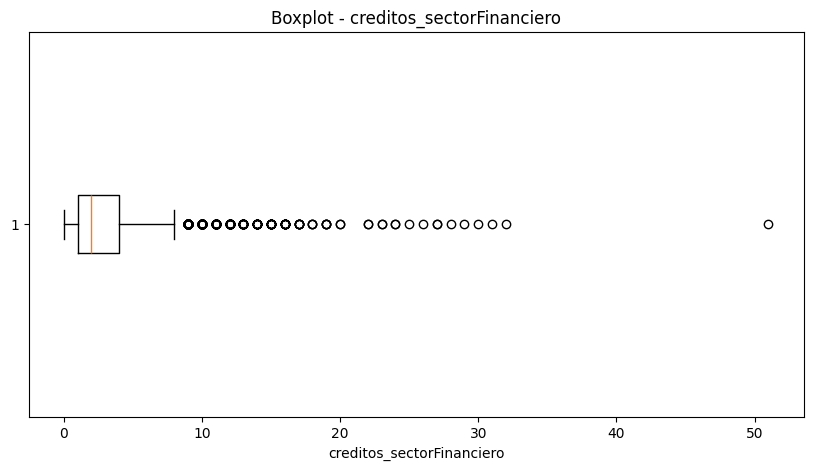

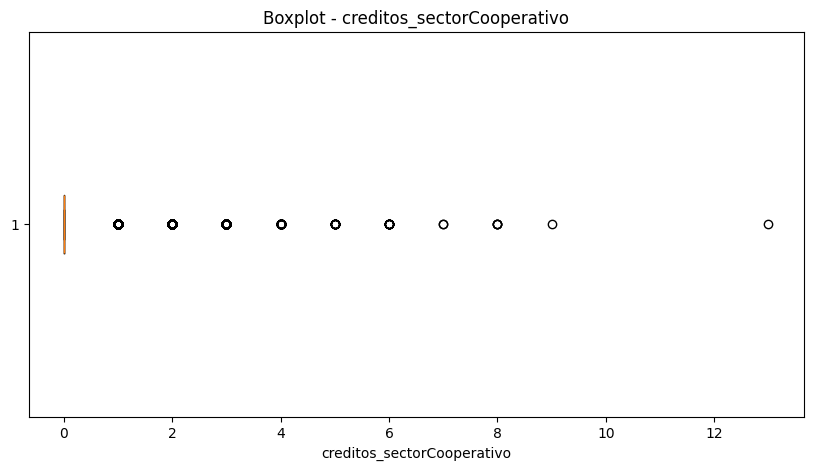

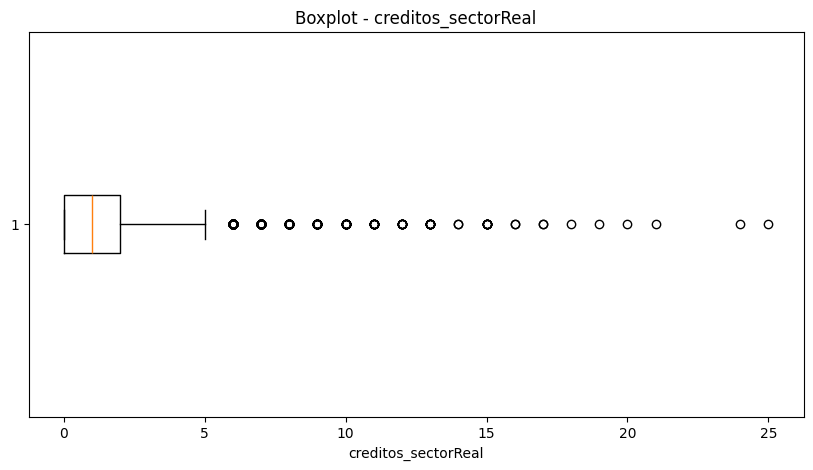

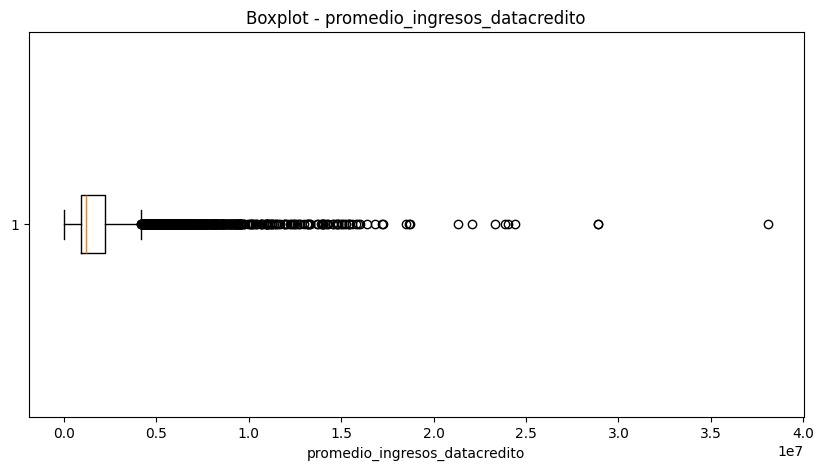

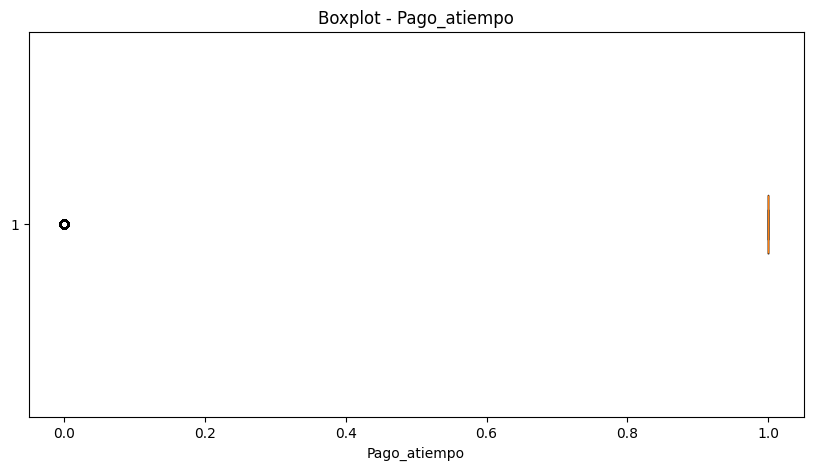

In [12]:
#Boxplots(outliers visuales)
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

Interpretación de Boxplots

Los boxplots permiten visualizar la dispersión, mediana y presencia de valores atípicos en las variables numéricas.

 Observaciones principales:

- Las variables financieras como capital_prestado, saldo_total, salario_cliente y promedio_ingresos_datacredito presentan fuerte asimetría positiva, evidenciada por:
  - Cajas comprimidas en valores bajos.
  - Bigotes superiores largos.
  - Presencia de múltiples valores atípicos.

- En la mayoría de los casos, los valores extremos corresponden a montos elevados que, si bien se clasifican como outliers estadísticos, pueden ser coherentes con el comportamiento del negocio financiero.

- Variables de conteo (como cantidad de créditos o huella de consulta) también presentan distribución sesgada hacia la derecha, lo cual es esperado en este tipo de datos.

Conclusión

Los valores atípicos detectados no parecen corresponder a errores de carga evidentes, sino a comportamiento natural del negocio.  

Por lo tanto, no se recomienda eliminarlos automáticamente. En etapas posteriores se evaluará:

- Aplicación de transformaciones logarítmicas.
- Escalado robusto.
- Evaluación del impacto de outliers en modelos predictivos.

7. Outliers: detección con IQR

En vez de “a ojo”, cuantificamos outliers usando IQR. Esto es importante para justificar decisiones en entregas.

In [13]:
def iqr_outliers_count(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return ((s < lower) | (s > upper)).sum(), lower, upper

outlier_report = []
for col in num_cols:
    c, lo, up = iqr_outliers_count(df[col].dropna())
    outlier_report.append([col, c, lo, up])

outlier_df = pd.DataFrame(outlier_report, columns=["variable", "outliers_count", "lower_bound", "upper_bound"])
outlier_df.sort_values("outliers_count", ascending=False)

,variable,outliers_count,lower_bound,upper_bound
16,creditos_sectorCooperativo,1895,0.000000e+00,0.000000e+00
7,puntaje,1326,9.522779e+01,9.522779e+01
12,saldo_total,969,-7.223825e+04,1.281238e+05
13,saldo_principal,951,-6.474500e+04,1.150790e+05
2,plazo_meses,869,-3.000000e+00,2.100000e+01
18,promedio_ingresos_datacredito,784,-1.034896e+06,4.191912e+06
6,cuota_pactada,756,-1.229805e+05,5.263675e+05
4,salario_cliente,657,-1.952500e+06,8.587500e+06
1,capital_prestado,516,-1.525436e+06,5.783034e+06
19,Pago_atiempo,500,1.000000e+00,1.000000e+00


8. Variables categóricas

Evaluamos distribución de categorías y desbalance.
Si una categoría domina demasiado, puede afectar modelos y métricas.

In [14]:
#Distribución de categóricas
for col in cat_cols:
    print("\n", col)
    display(df[col].value_counts())
    display((df[col].value_counts(normalize=True) * 100).round(2))


 fecha_prestamo


fecha_prestamo
2025-04-10 18:14:34    2
2025-01-30 16:25:43    2
2025-03-24 10:01:50    2
2025-08-05 10:06:12    2
2025-01-17 18:49:21    2
                      ..
2025-06-05 11:17:18    1
2025-05-08 15:03:19    1
2025-06-27 10:59:05    1
2025-12-04 14:54:20    1
2025-01-12 10:36:12    1
Name: count, Length: 10608, dtype: int64

fecha_prestamo
2025-04-10 18:14:34    0.02
2025-01-30 16:25:43    0.02
2025-03-24 10:01:50    0.02
2025-08-05 10:06:12    0.02
2025-01-17 18:49:21    0.02
                       ... 
2025-06-05 11:17:18    0.01
2025-05-08 15:03:19    0.01
2025-06-27 10:59:05    0.01
2025-12-04 14:54:20    0.01
2025-01-12 10:36:12    0.01
Name: proportion, Length: 10608, dtype: float64


 tipo_laboral


tipo_laboral
Empleado         6604
Independiente    4009
Name: count, dtype: int64

tipo_laboral
Empleado         62.23
Independiente    37.77
Name: proportion, dtype: float64


 tendencia_ingresos


tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
               ... 
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, Length: 46, dtype: int64

tendencia_ingresos
Creciente      67.60
Decreciente    16.49
Estable        15.17
0               0.09
8315            0.08
               ...  
-101368         0.01
86286           0.01
65988           0.01
77975           0.01
-224714         0.01
Name: proportion, Length: 46, dtype: float64

### Analisis Bivariado

10. Relaciones clave

Elegimos 2–4 relaciones “con sentido negocio” para analizar.

-capital_prestado vs plazo_meses

-edad_cliente vs capital_prestado

-tipo_credito vs capital_prestado

 Interpretación - Análisis Bivariable

1️⃣ Capital prestado vs Plazo (meses)

El gráfico de dispersión muestra una relación positiva moderada entre el plazo del crédito y el capital prestado.

A medida que aumenta el plazo, se observa una tendencia a mayores montos de capital, lo cual es coherente con la lógica financiera: créditos de mayor duración suelen asociarse a montos más elevados.

Sin embargo:
- Existe alta dispersión para plazos similares.
- Se observan valores extremos (outliers) con montos significativamente superiores.
- No se evidencia una relación lineal perfecta.

Esto sugiere que el plazo influye en el capital, pero no es el único factor determinante.

---

2️⃣ Capital prestado vs Tipo de crédito

El boxplot evidencia diferencias claras en la distribución del capital prestado según el tipo de crédito.

Observaciones relevantes:

- Algunos tipos de crédito presentan medianas considerablemente mayores.
- La dispersión varía entre categorías.
- Existen outliers en múltiples tipos de crédito, lo cual es consistente con comportamiento financiero real.

Esto indica que el tipo de crédito es una variable relevante en la determinación del monto otorgado, y podría tener valor predictivo en modelos posteriores.

---

 Conclusión Bivariable

Las relaciones analizadas muestran coherencia con la lógica del negocio financiero:

- El plazo se asocia con el monto del crédito.
- El tipo de crédito influye en la magnitud del capital otorgado.

Estas variables podrían ser determinantes importantes en etapas de modelado supervisado.

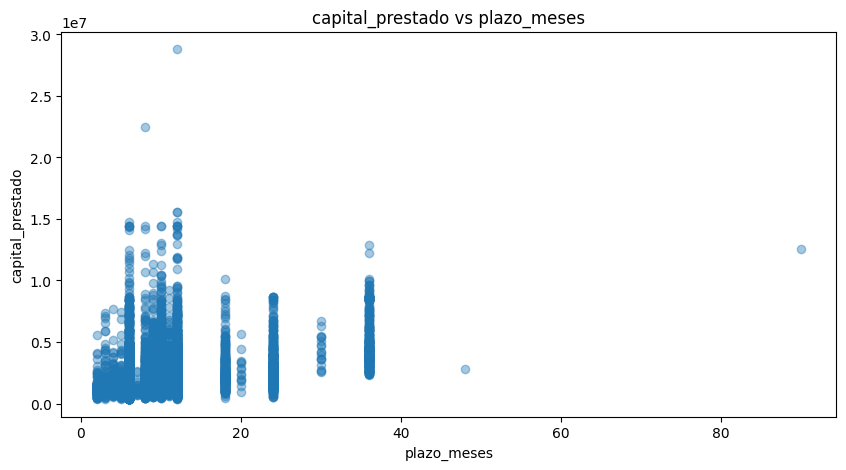

In [16]:
#Scatter: capital vs plazo
plt.figure()
plt.scatter(df["plazo_meses"], df["capital_prestado"], alpha=0.4)
plt.title("capital_prestado vs plazo_meses")
plt.xlabel("plazo_meses")
plt.ylabel("capital_prestado")
plt.show()

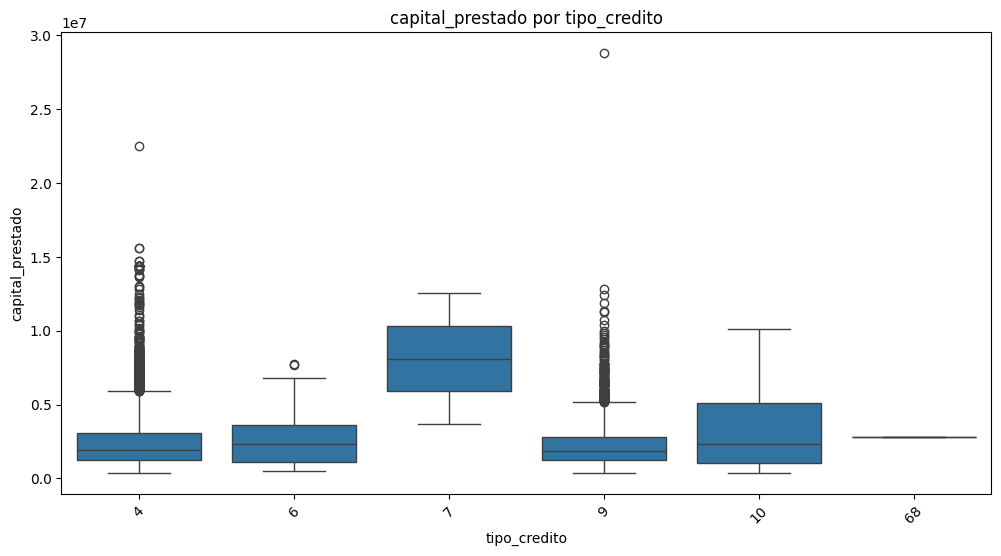

In [17]:
#Boxplot: capital por tipo_credito
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="tipo_credito", y="capital_prestado")
plt.title("capital_prestado por tipo_credito")
plt.xticks(rotation=45)
plt.show()

### Analisis Multivariado

9. Correlaciones (numéricas)

La matriz de correlación nos muestra relaciones lineales.
Ayuda a detectar colinealidad, redundancias y variables fuertes para predicción.

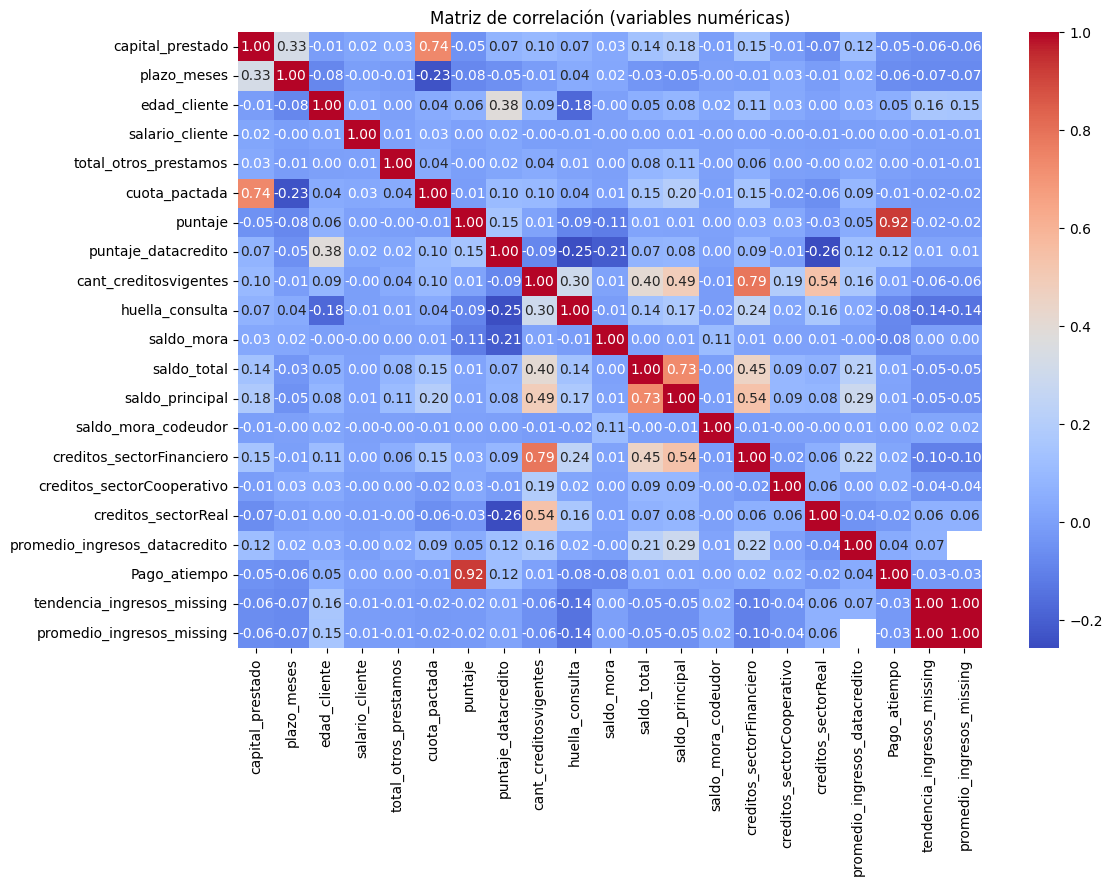

In [29]:
#Heatmap
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

Se observa correlación positiva entre variables de saldo y capital,
lo cual es consistente con comportamiento financiero esperado.
No se identifican correlaciones críticas que sugieran multicolinealidad severa.

## 11. Hallazgos y Conclusiones

 11.1 Calidad del dataset

El dataset presenta buena integridad estructural.
No se detectaron registros duplicados y la mayoría de las variables
presentan bajo porcentaje de valores faltantes.

Sin embargo, las variables tendencia_ingresos y
promedio_ingresos_datacredito presentan aproximadamente un 26% de missing,
con patrón dependiente de tipo_credito, lo que indica que la ausencia
de información no es completamente aleatoria.

Se generaron variables indicadoras de missing para preservar
posible señal predictiva.

---

 11.2 Distribución de variables numéricas

La mayoría de variables financieras presentan fuerte asimetría positiva,
con concentración en valores bajos y colas largas hacia valores elevados.

Este comportamiento es consistente con datos crediticios,
donde pocos clientes concentran montos significativamente altos.

Se recomienda evaluar:

- Transformaciones logarítmicas
- Escalado robusto
- Tratamiento específico de outliers en modelado

---
 11.3 Outliers

Los boxplots confirman la presencia de valores extremos en variables monetarias.
No obstante, estos valores pueden ser representativos del negocio
y no necesariamente errores de carga.

Se sugiere no eliminarlos automáticamente, sino evaluar su impacto
durante el proceso de modelado.

---

 11.4 Variables categóricas

La variable tipo_credito muestra alta concentración en pocas categorías,
lo que evidencia estructura estandarizada de productos financieros.

La variable Pago_a_tiempo presenta desbalance hacia la categoría positiva,
lo que podría requerir técnicas de balanceo si se utiliza como variable objetivo.

---

11.5 Correlaciones

No se evidencian correlaciones extremadamente altas entre variables numéricas,
lo que sugiere ausencia de multicolinealidad severa.

Se observan relaciones coherentes entre variables relacionadas con saldos
y montos financieros.

---

11.6 Próximos pasos

A partir del EDA realizado, los siguientes pasos recomendados son:

- Definir estrategia de imputación para variables con missing significativo.
- Aplicar transformaciones a variables altamente asimétricas.
- Evaluar tratamiento de outliers según modelo a implementar.
- Preparar pipeline de preprocesamiento para modelado supervisado.